In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_style("whitegrid")

In [6]:
import pandas as pd

# Carregar os datasets
df_red = pd.read_csv("winequality-red.csv", sep=';')
df_white = pd.read_csv("winequality-white.csv", sep=';')

In [7]:
df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [9]:
#juntar os datasets
df_red["type"] = "red"
df_white["type"] = "white"

df = pd.concat([df_red, df_white], ignore_index=True)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [10]:
#Número total de vinhos e Número total de variáveis


df.shape

(6497, 13)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


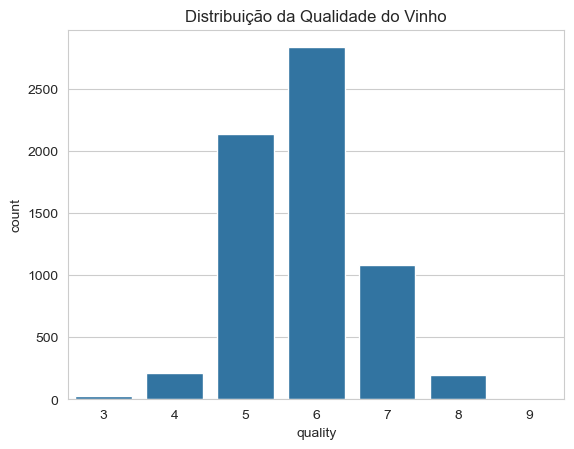

In [ ]:
sns.countplot(x="quality", data=df)
plt.title("Distribuição da Qualidade do Vinho")
plt.show()
#vamos ver quantos vinhos existem em cada nível de qualidade.

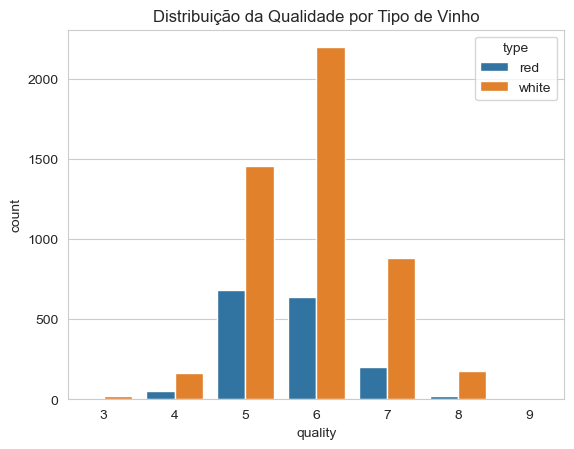

In [ ]:
sns.countplot(x="quality", hue="type", data=df)
plt.title("Distribuição da Qualidade por Tipo de Vinho")
plt.show()
#Comparar a qualidade média entre vinhos tintos e brancos

In [ ]:
#Calcular a matriz de correlação
corr_matrix = df.corr(numeric_only=True)
corr_matrix


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,-0.076743
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,-0.265699
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,0.085532
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,-0.036980
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,-0.200666
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,0.055463
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,-0.041385
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,-0.305858
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,0.019506
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,0.038485


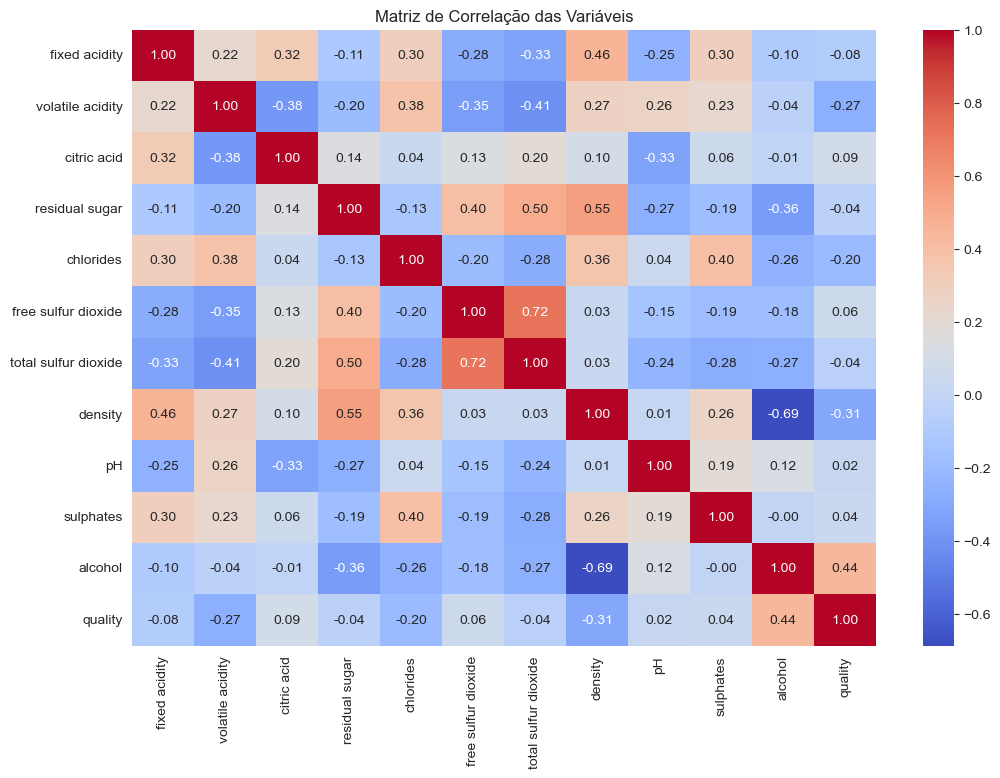

In [ ]:
#Matriz de correlação 
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação das Variáveis")
plt.show()

In [ ]:
# ver apenas as correlações com a qualidade
corr_matrix["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64

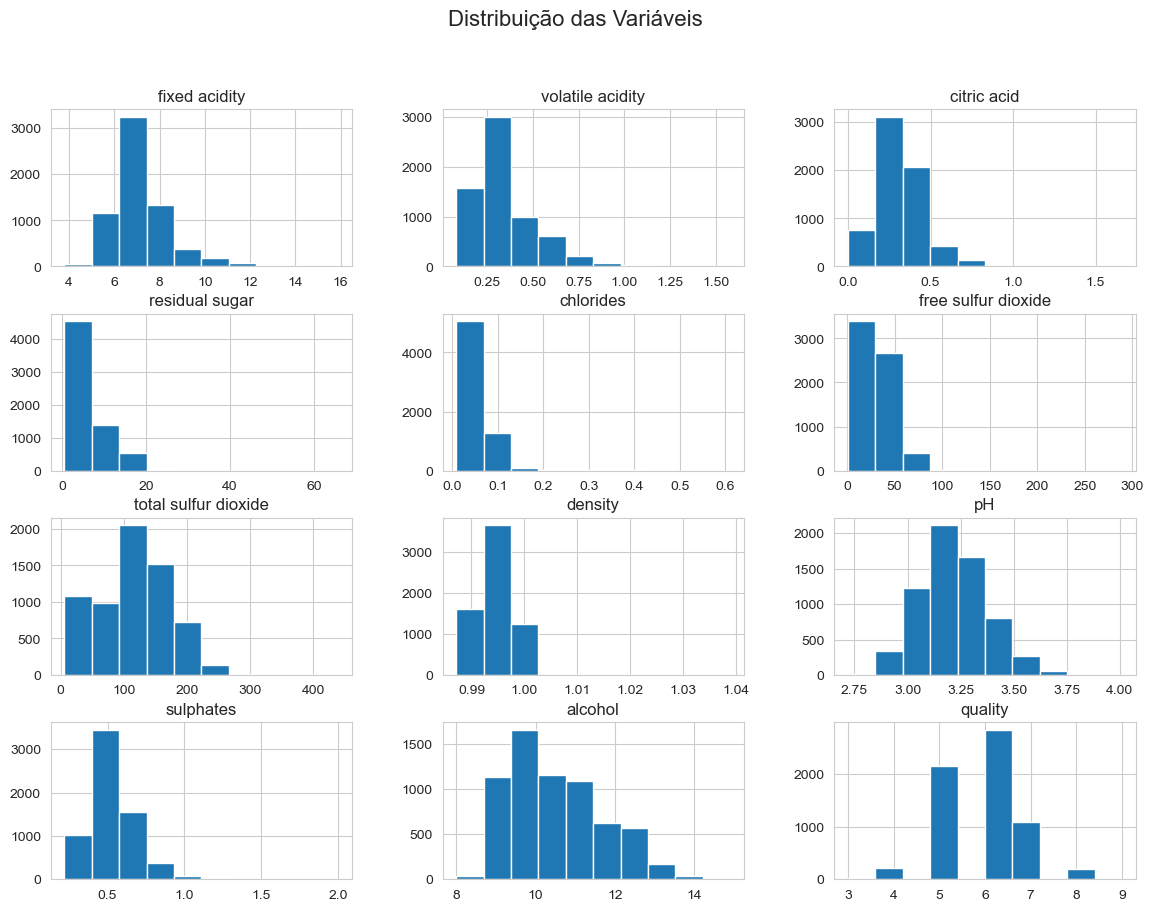

In [ ]:
#Histogramas das variáveis (distribuição)
df.hist(figsize=(14,10))
plt.suptitle("Distribuição das Variáveis", fontsize=16)
plt.show()

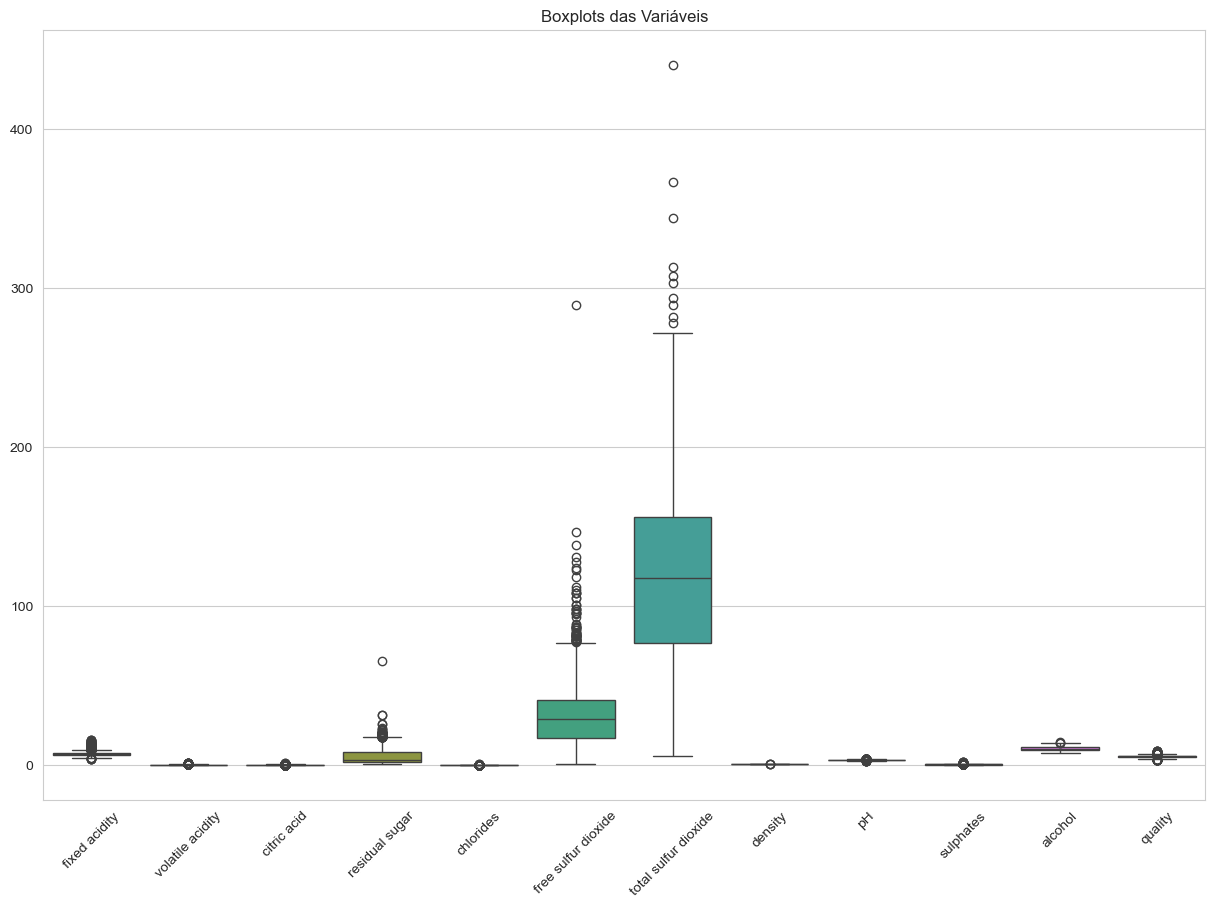

In [ ]:
#Boxplots para identificar outliers
plt.figure(figsize=(15,10))
sns.boxplot(data=df.drop("type", axis=1))
plt.title("Boxplots das Variáveis")
plt.xticks(rotation=45)
plt.show()

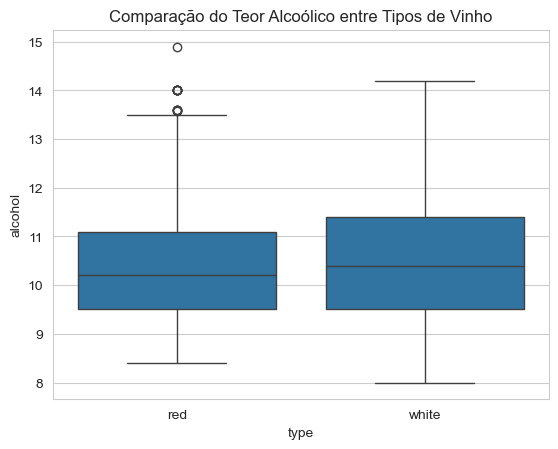

In [ ]:
#comparar diferenças entre os dois tipos de vinho, aqui vamos comparar o teor alcoólico entre vinhos tintos e brancos.
sns.boxplot(x="type", y="alcohol", data=df)
plt.title("Comparação do Teor Alcoólico entre Tipos de Vinho")
plt.show()

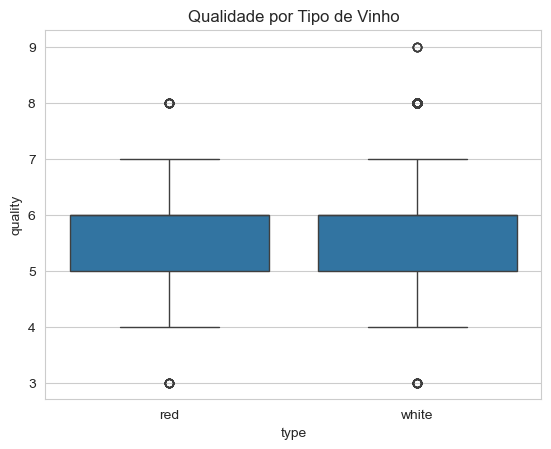

In [ ]:
#qualidade
sns.boxplot(x="type", y="quality", data=df)
plt.title("Qualidade por Tipo de Vinho")
plt.show()

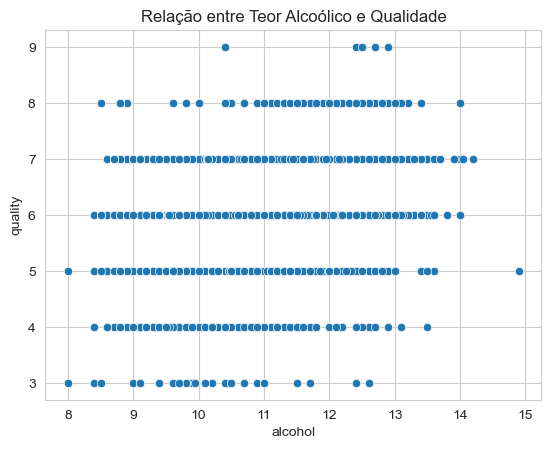

In [ ]:
# Relação 1 entre teor alcoólico e qualidade
sns.scatterplot(x="alcohol", y="quality", data=df)
plt.title("Relação entre Teor Alcoólico e Qualidade")
plt.show()

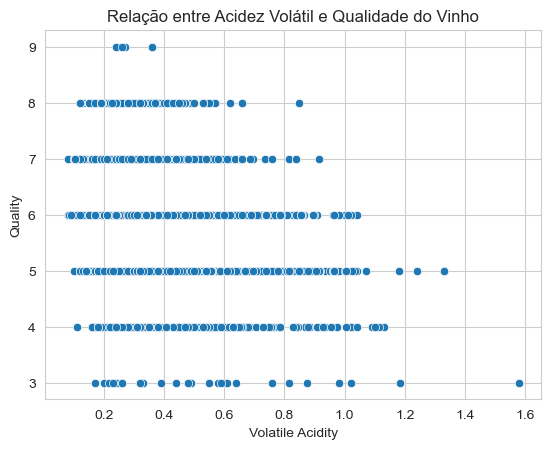

In [ ]:
# Relação 2 entre acidez volátil e qualidade
sns.scatterplot(x="volatile acidity", y="quality", data=df)

plt.title("Relação entre Acidez Volátil e Qualidade do Vinho")
plt.xlabel("Volatile Acidity")
plt.ylabel("Quality")

plt.show()

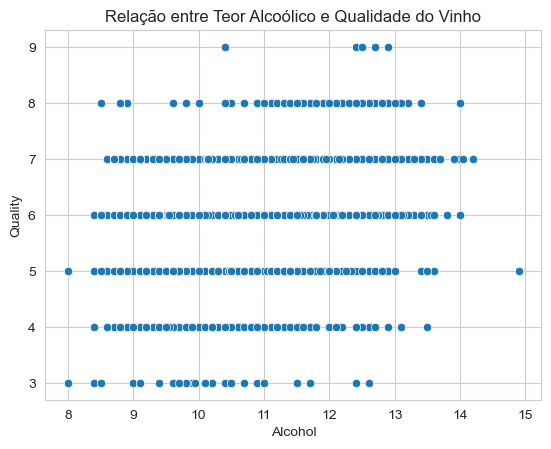

In [ ]:
X = df[["alcohol"]]
y = df["quality"]

#Aqui vamos criar um modelo
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
#Obter os coeficientes
intercept = model.intercept_
slope = model.coef_[0]

print("Intercepto:", intercept)
print("Coeficiente:", slope)

Intercepto: 2.405268601556653
Coeficiente: 0.3253120380535125


In [ ]:
#Calcular o R²
r2 = model.score(X, y)
print("R²:", r2)

R²: 0.1974189472217922


In [4]:
#desenhar a reta de regressão
sns.regplot(x="alcohol", y="quality", data=df)

plt.title("Regressão Linear: Alcohol vs Quality")
plt.show()

NameError: name 'sns' is not defined

In [13]:
#verificar o ponto das médias
mean_x = X['alcohol'].mean()
mean_y = y.mean()

print("Média de X:", mean_x)
print("Média de Y:", mean_y)

NameError: name 'X' is not defined

In [ ]:
#verificar se a equação da reta passa pelos pontos
predicted_y = intercept + slope * mean_x

print("Valor previsto no ponto médio:", predicted_y)

Valor previsto no ponto médio: 5.818377712790519


In [ ]:
X2 = df[["volatile acidity"]]
y2 = df["quality"]
model2 = LinearRegression()
model2.fit(X2, y2)

LinearRegression()

In [ ]:
#obter os coeficientes
intercept2 = model2.intercept_
slope2 = model2.coef_[0]

print("Intercepto:", intercept2)
print("Coeficiente:", slope2)

Intercepto: 6.297071660451916
Coeficiente: -1.4093078144272027


In [ ]:
# cacular o R² para o segundo modelo
r2_2 = model2.score(X2, y2)
print("R²:", r2_2)

R²: 0.07059621240300684


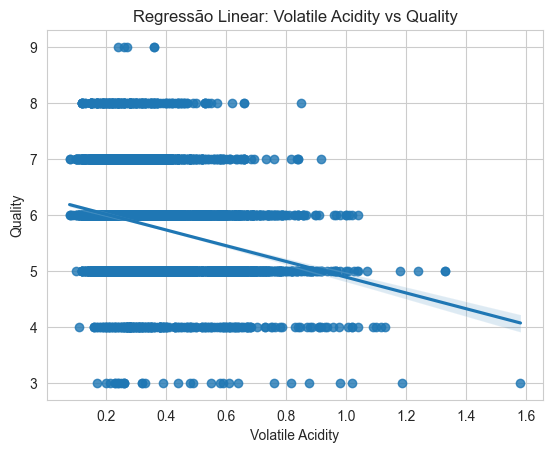

In [14]:
# gerar o gráfico de regressão para o segundo modelo
sns.regplot(x="volatile acidity", y="quality", data=df)

plt.title("Regressão Linear: Volatile Acidity vs Quality")
plt.xlabel("Volatile Acidity")
plt.ylabel("Quality")

plt.show()

In [15]:
#verificar se o ponto das médias 
mean_x2 = X2.mean()[0]
mean_y2 = y2.mean()

print("Média de X:", mean_x2)
print("Média de Y:", mean_y2)

NameError: name 'X2' is not defined

In [16]:
#verificar se a reta passa neses pontos
predicted_y2 = intercept2 + slope2 * mean_x2

print("Valor previsto:", predicted_y2)

NameError: name 'intercept2' is not defined

In [17]:
#inverter a relação
X_inv = df[["quality"]]
y_inv = df["alcohol"]
model_inv = LinearRegression()
model_inv.fit(X_inv, y_inv)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
# ver os coeficientes do modelo invertido
intercept_inv = model_inv.intercept_
slope_inv = model_inv.coef_[0]

print("Intercepto:", intercept_inv)
print("Coeficiente:", slope_inv)

Intercepto: 6.960858633406994
Coeficiente: 0.6068602576253834


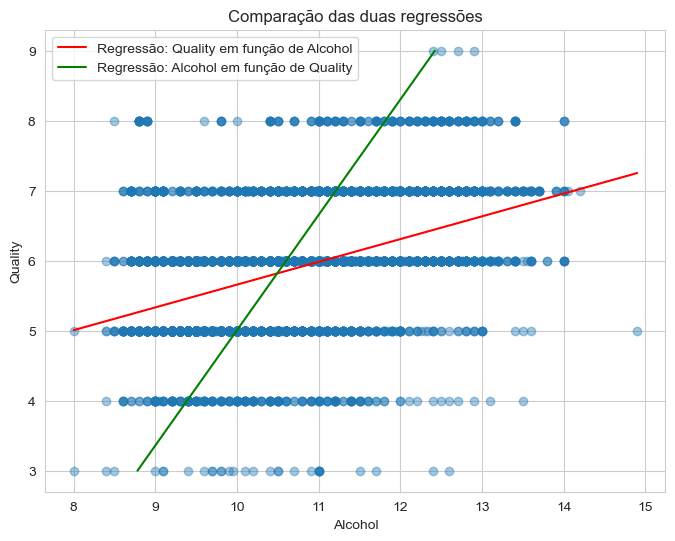

In [49]:
# desenhar as dua retas no mesmo gráfico

plt.figure(figsize=(8,6))

# scatter dos dados
plt.scatter(df["alcohol"], df["quality"], alpha=0.4)

# reta Y em função de X
x_vals = np.linspace(df["alcohol"].min(), df["alcohol"].max(), 100)
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color="red", label="Regressão: Quality em função de Alcohol")

# reta X em função de Y (convertida para o mesmo gráfico)
y_vals2 = np.linspace(df["quality"].min(), df["quality"].max(), 100)
x_vals2 = intercept_inv + slope_inv * y_vals2
plt.plot(x_vals2, y_vals2, color="green", label="Regressão: Alcohol em função de Quality")

plt.xlabel("Alcohol")
plt.ylabel("Quality")

plt.title("Comparação das duas regressões")
plt.legend()

plt.show()

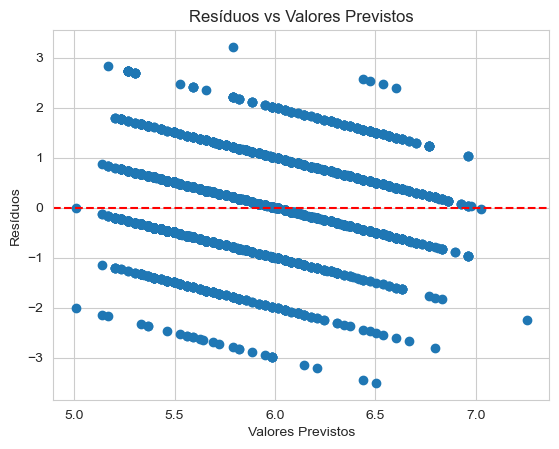

In [ ]:
#vamos calcular os valores previstos, os resíduos e fazer um Gráfico resíduos vs valores previstos
y_pred = model.predict(X)

residuals = y - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Valores Previstos")
plt.ylabel("Resíduos")

plt.title("Resíduos vs Valores Previstos")

plt.show()

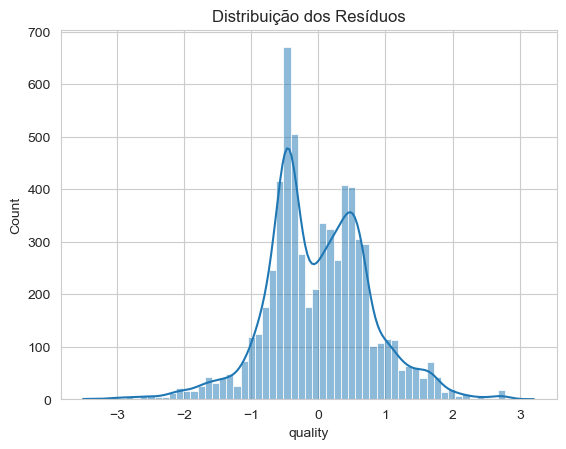

In [53]:
#Histograma dos resíduos

sns.histplot(residuals, kde=True)

plt.title("Distribuição dos Resíduos")

plt.show()

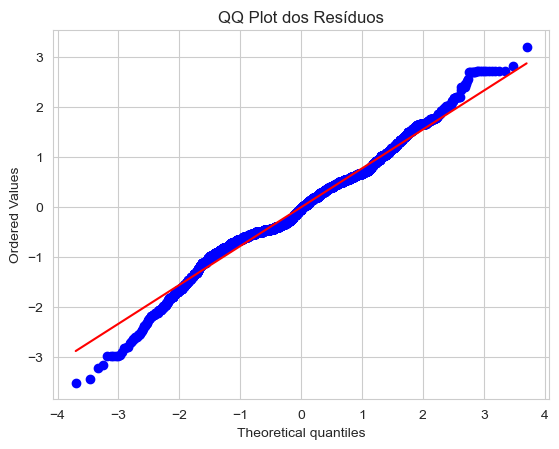

In [54]:
#QQ Plot (teste visual de normalidade)
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("QQ Plot dos Resíduos")

plt.show()